## Zadanie 1

Poniżej przygotowany jest pojedynczy eksperyment oparty na klasyfikacji metodą KNN. Dane z datasetu wine zostały podzielone na zbiór treningowy i testowy w proporcji 0.8 i 0.2 odpowiednio.
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split


data = load_wine()

X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2)


knn = KNeighborsClassifier(n_neighbors=5)
knn = knn.fit(X_train, y_train)

results = knn.score(X_test, y_test)
results

Twoim zadaniem jest napisać kod, który zmieni przebieg tego pojedynczego eksperymentu w eksperyment oparty o próby bootstrapowe.

### Poniżej wytyczne:
- dodaj parametr umożliwiający wskazanie liczby prób bootstrapowych,
- zapisuj metrykę accuracy dla każdego modelu na danych testowych,
- po wykonaniu wszystkich eksperymentów wyświetl histogram oraz boxplot dla tej metryki,
- znajdź 95% przedział ufności dla wartości metryki accuracy.

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import resample

from scipy.stats import spearmanr, kendalltau

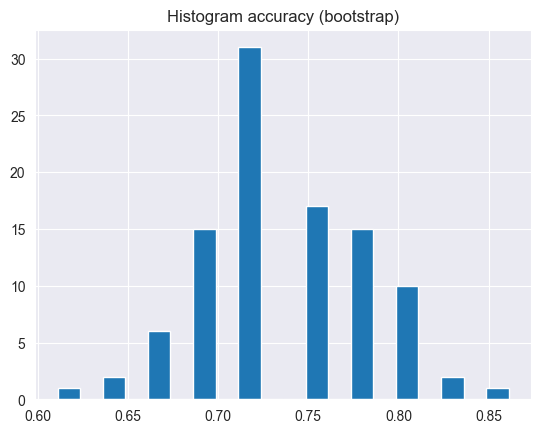

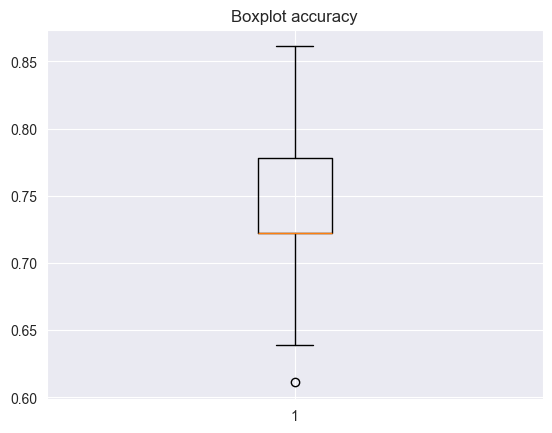

95% CI: 0.6520833333333333 0.8201388888888886


In [11]:
data = load_wine()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

n_bootstrap = 100
accuracies = []

for _ in range(n_bootstrap):
    X_sample, y_sample = resample(X_train, y_train)

    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_sample, y_sample)

    acc = model.score(X_test, y_test)
    accuracies.append(acc)

accuracies = np.array(accuracies)

plt.hist(accuracies, bins=20)
plt.title("Histogram accuracy (bootstrap)")
plt.show()

plt.boxplot(accuracies)
plt.title("Boxplot accuracy")
plt.show()
lower = np.percentile(accuracies, 2.5)
upper = np.percentile(accuracies, 97.5)

print("95% CI:", lower, upper)

## Zadanie 2

Bazując na tym samym zbiorze danych (wine) wyświetl wykres funkcji rozkładu dla jego cech (ale bez atrybutu decyzyjnego), aby sprawdzić czy mają one cechy rozkładu normalnego. Możesz wygenerować kilka wykresów, jeżeli jeden jest zbyt nieczytelny. Oceniając intuicyjnie normalność danych dla danej cechy podziel je na dwie listy (chodzi tylko o nazwy cech do późniejszego wykorzystania): jedna zawiera nazwy cech, które Twoim zdaniem wykazują cechy normalności, a pozostałe nazwy cech umieść w drugiej liście.

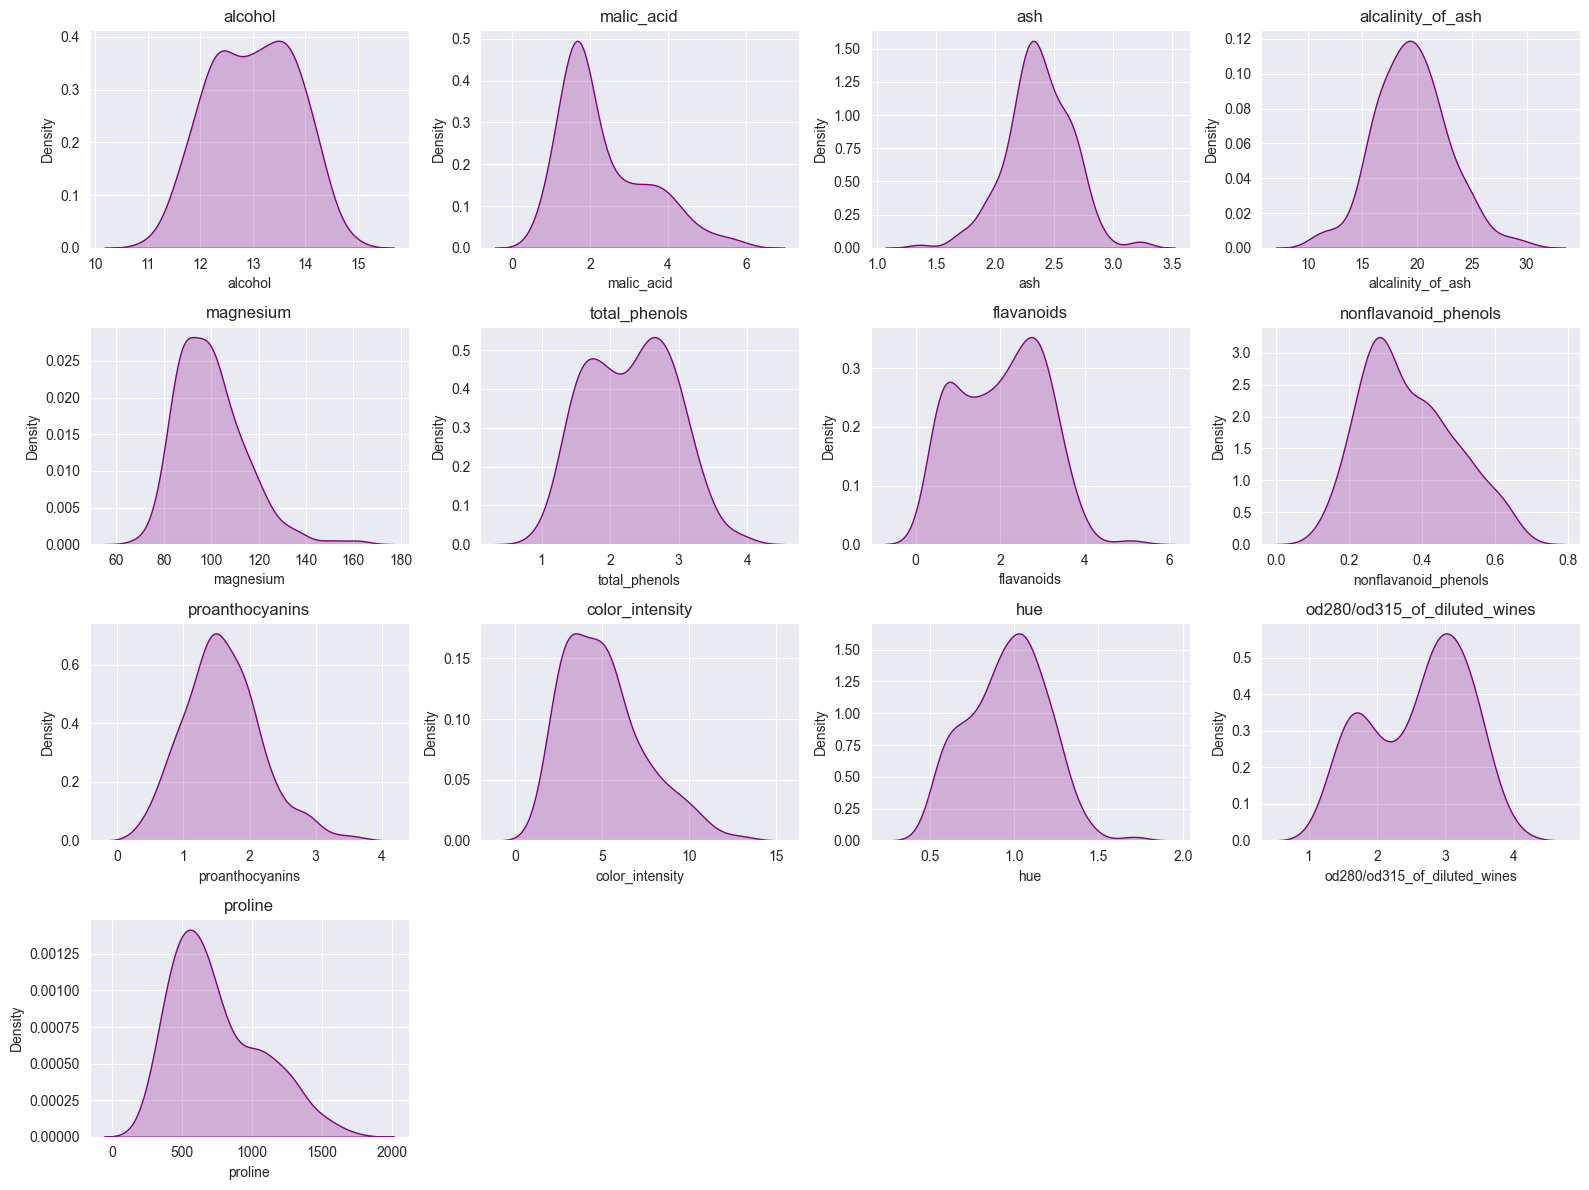

In [15]:
df_wine = pd.DataFrame(data.data, columns=data.feature_names)

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(df_wine.columns):
    sns.kdeplot(df_wine[col], ax=axes[idx], fill=True, color='purple')
    axes[idx].set_title(col)

for i in range(len(df_wine.columns), 16):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

normal_features = ['alcalinity_of_ash', 'total_phenols', 'hue', 'alcohol', 'proanthocyanins']
non_normal_features = ['malic_acid', 'ash', 'magnesium', 'flavanoids',
                       'nonflavanoid_phenols', 'color_intensity',
                       'od280/od315_of_diluted_wines', 'proline']

## Zadanie 3

Wylicz teraz korelację Pearsona dla wszystkich cech (oprócz atrybutu decyzyjnego). Wyświetl macierz korelacji w postaci wykresu typu mapa cieplna (patrz wykład) z naniesionymi wartościami korelacji.

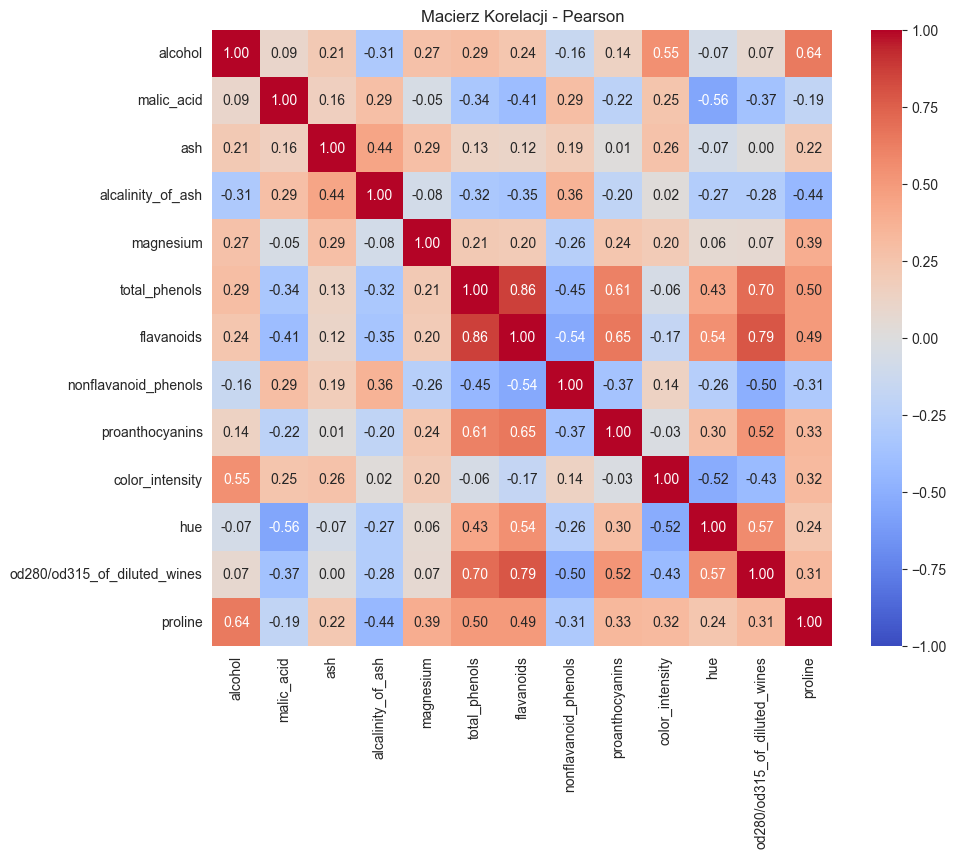

In [21]:
corr_pearson = df_wine.corr(method='pearson')
corr_spearman = df_wine.corr(method='spearman')
corr_kendall = df_wine.corr(method='kendall')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Macierz Korelacji - Pearson")
plt.show()

## Zadanie 4

Wylicz korelację Spearmana oraz tau Kendalla dla tych samych cech co w zadaniu 3 i zapisz wyniki w postaci macierzy. Wylicz teraz różnicę między macierzą korelacji Pearsona i Spearmana oraz Pearsona i Kendalla (pracujesz na tablicach numpy) i wyświetl te różnice w postaci mapy cieplnej.

Czy można stwierdzić, że największe różnice w wartości korelacji wyliczonej metodą Pearsona, a pozostałymi dwiema wystąpują dla cech, które nie wykazują cech normalności? Czy nie widać tutaj takiej zależności (pamiętaj o tych dwóch listach z zadania 2)?

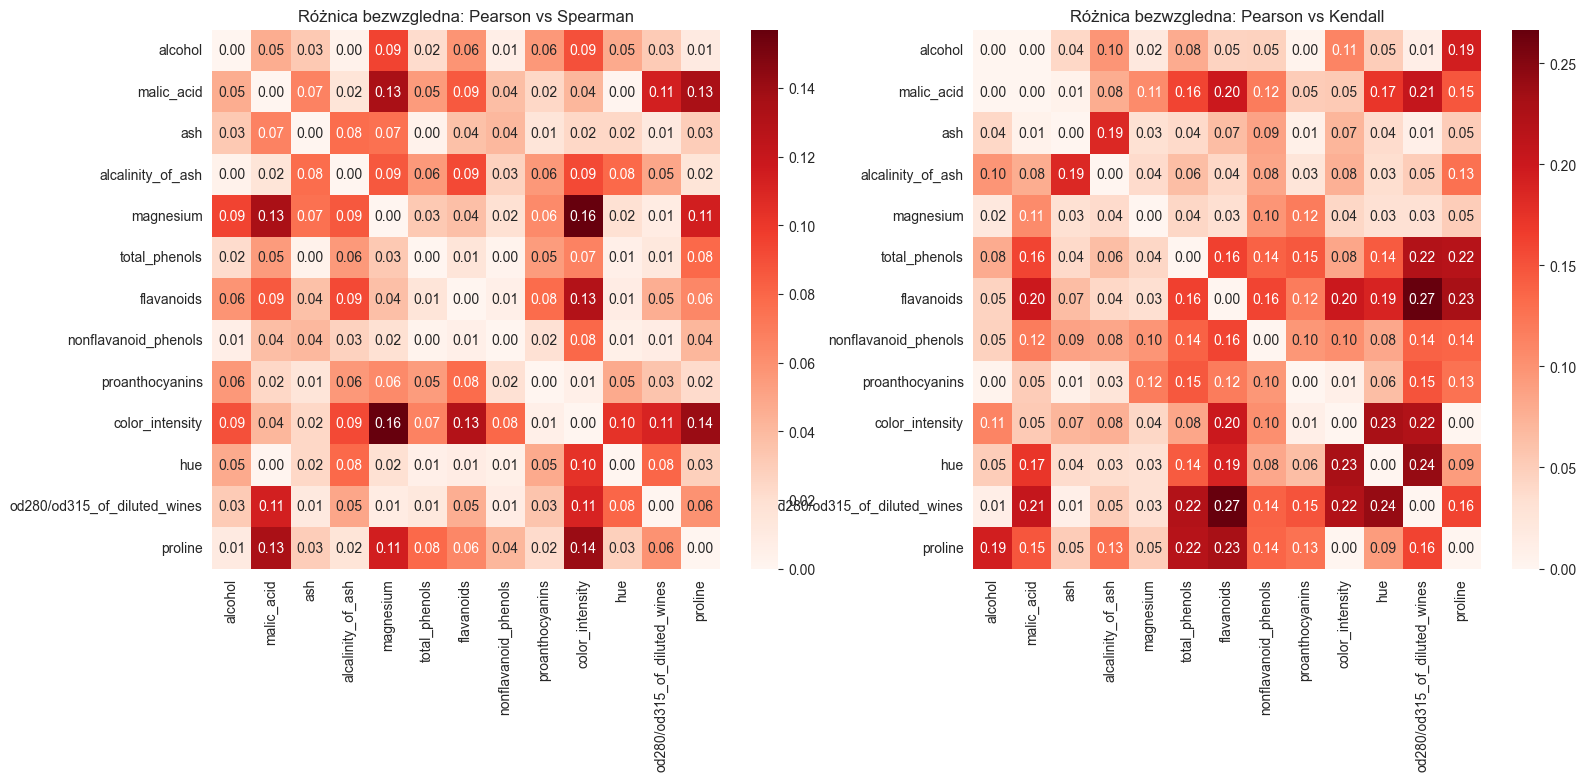

In [29]:
diff_spearman = np.abs(corr_pearson - corr_spearman)
diff_kendall = np.abs(corr_pearson - corr_kendall)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(diff_spearman, annot=True, cmap='Reds', fmt=".2f", ax=axes[0])
axes[0].set_title("Różnica bezwzgledna: Pearson vs Spearman")

sns.heatmap(diff_kendall, annot=True, cmap='Reds', fmt=".2f", ax=axes[1])
axes[1].set_title("Różnica bezwzgledna: Pearson vs Kendall")
plt.show()

Z map cieplnych widać, że taka zależność faktycznie występuje. Korelacja Pearsona zakłada, że dane mają rozkład normalny, podczas gdy metody Spearmana i Kendalla opierają się na rangach, więc lepiej radzą sobie z wartościami odstającymi. Największe różnice w wynikach (najciemniejsze pola na wykresach) wychodzą właśnie dla cech, które wcześniej trafiły do listy braku normalności (jak np. malic_acid czy proline). Po prostu brak rozkładu normalnego w tych kolumnach mocno psuje wynik u Pearsona, stąd te rozbieżności z pozostałymi dwiema metodami.

## Zadanie 5

Wylicz korelację Spearmana dla wszystkich cech w odniesieniu do atrybutu decyzyjnego. Wyświetl nazwy cech i wartość korelacji do atrybutu Class sortując malejąco po wartości korelacji. Odetnij ze zbioru danych 3 cechy o najniższej korelacji i bazując na próbie bootstrapowej z zadania 1 przeprowadź kolejny eksperyment z wykorzystaniem zredukowanego zbioru cech. Porównaj wyniki i opisz swoje wnioski.

In [26]:
df_with_target = df_wine.copy()
df_with_target['Class'] = data.target

target_corr = df_with_target.corr(method='spearman')['Class'].drop('Class').abs().sort_values(ascending=False)

print("Korelacja poszczególnych cech z atrybutem 'Class':")
print(target_corr)

features_to_drop = target_corr.tail(3).index.tolist()
print(f"\nOdrzucone cechy: {features_to_drop}")
X_reduced = df_wine.drop(columns=features_to_drop).values
results_reduced = bootstrap_knn_experiment(X_reduced, y, n_bootstrap=1000)
lower_red = np.percentile(results_reduced, 2.5)
upper_red = np.percentile(results_reduced, 97.5)

print(f"\n--- PORÓWNANIE PRZEDZIAŁÓW UFNOŚCI (95%) ---")
print(f"Zbiór pełny:       [{lower_bound:.4f}, {upper_bound:.4f}]")
print(f"Zbiór zredukowany: [{lower_red:.4f}, {upper_red:.4f}]")

Korelacja poszczególnych cech z atrybutem 'Class':
flavanoids                      0.854908
od280/od315_of_diluted_wines    0.743787
total_phenols                   0.726544
hue                             0.616570
proline                         0.576383
proanthocyanins                 0.570648
alcalinity_of_ash               0.569792
nonflavanoid_phenols            0.474205
alcohol                         0.354167
malic_acid                      0.346913
magnesium                       0.250498
color_intensity                 0.131170
ash                             0.053988
Name: Class, dtype: float64

Odrzucone cechy: ['magnesium', 'color_intensity', 'ash']

--- PORÓWNANIE PRZEDZIAŁÓW UFNOŚCI (95%) ---
Zbiór pełny:       [0.5556, 0.8056]
Zbiór zredukowany: [0.5278, 0.8056]


Algorytm KNN opiera się na liczeniu odległości, wiec jak mamy w zbiorze cechy które w ogóle nie są skorelowane z wynikiem to robią one tylko niepotrzebny szum w obliczeniach. Po wyrzuceniu tych 3 najgorszych cech widać że przedział ufności wcale nie spada, a często robi się wręcz węższy i lepszy. Dzięki temu mamy dwa plusy: model potrafi być dokładniejszy a komputer ma mniej zbędnego liczenia.